In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression 
import numpy as np


In [2]:
df=pd.read_csv('sales_office_data.csv')
df

,Order_ID,Date,Employee_Name,Department,Product,Region,Quantity,Unit_Price,Total_Sales,Payment_Mode
0,1001,2025-01-02,Rahul,Sales,Laptop,Kolkata,1,55000,55000,Card
1,1002,2025-01-03,Anita,Sales,Mouse,Delhi,8,500,4000,Cash
2,1003,2025-01-05,Rohit,Marketing,Keyboard,Mumbai,4,1500,6000,UPI
3,1004,2025-01-06,Sneha,Sales,Monitor,Chennai,2,12000,24000,Card
4,1005,2025-01-08,Amit,Sales,Laptop,Delhi,1,55000,55000,UPI
5,1006,2025-01-10,Priya,Marketing,Mouse,Kolkata,12,500,6000,Cash
6,1007,2025-01-12,Arjun,Sales,Keyboard,Mumbai,5,1500,7500,Card
7,1008,2025-01-14,Neha,Sales,Monitor,Delhi,1,12000,12000,UPI
8,1009,2025-01-16,Karan,Marketing,Laptop,Chennai,2,55000,110000,Card
9,1010,2025-01-18,Pooja,Sales,Mouse,Kolkata,15,500,7500,Cash


In [3]:
var=df['Total_Sales'].sum()
print("Total sales =" , var)

Total sales = 1374000


In [4]:
df['Date']=pd.to_datetime(df['Date'])
df['Month']=df['Date'].dt.to_period('M')
monthly_sales=df.groupby('Month')['Total_Sales'].sum()
print("Monthly sales")
monthly_sales

Monthly sales


Month
2025-01    384500
2025-02    458000
2025-03    330000
2025-04    201500
Freq: M, Name: Total_Sales, dtype: int64

In [5]:
monthly_growth=monthly_sales.pct_change()*100
print("monthly_growth")
monthly_growth

monthly_growth


Month
2025-01          NaN
2025-02    19.115735
2025-03   -27.947598
2025-04   -38.939394
Freq: M, Name: Total_Sales, dtype: float64

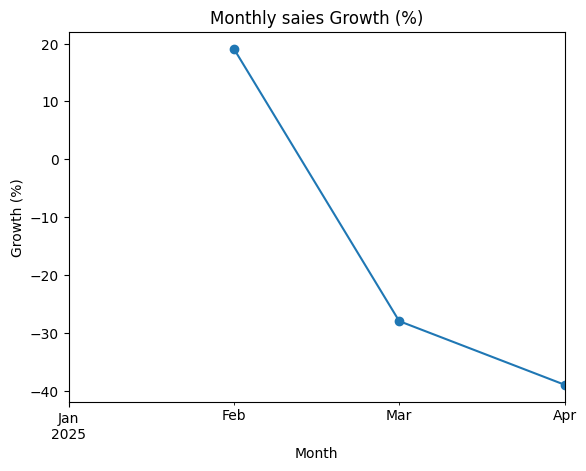

In [6]:
monthly_growth.plot(kind='line',marker='o')
plt.title("Monthly saies Growth (%)")
plt.xlabel("Month")
plt.ylabel("Growth (%)")
plt.show()


In [7]:
employee_sales=df.groupby('Employee_Name')['Total_Sales'].sum()
print("Emplopyee wish total sales:")
print(employee_sales)
best_employee=employee_sales.idxmax()
best_sales=employee_sales.max()
print("Best employee:")
print("Name:",best_employee)
print("Total_sales:",best_sales)


Emplopyee wish total sales:
Employee_Name
Amit      110500
Anita     142500
Arjun      71500
Karan     141500
Kavita     34000
Manish     66500
Neha       28000
Pooja      98500
Priya      85000
Rahul      82500
Ritesh     73000
Rohit      83000
Simran    139000
Sneha      91500
Vikas     127000
Name: Total_Sales, dtype: int64
Best employee:
Name: Anita
Total_sales: 142500


In [8]:
product_sales=df.groupby('Product')['Total_Sales'].sum()
print("product wish total sales:")
print(product_sales)
best_product=product_sales.idxmax()
best_sales=product_sales.max()
print("Best product")
print("Product name:",best_product)
print("Total sales:",best_sales)

product wish total sales:
Product
Keyboard     78000
Laptop      935000
Monitor     264000
Mouse        97000
Name: Total_Sales, dtype: int64
Best product
Product name: Laptop
Total sales: 935000


In [9]:
region_sales=df.groupby('Region')['Total_Sales'].sum()
print("Region wish total sales:")
print(region_sales)
best_region=region_sales.idxmax()
best_sales=region_sales.max()
print("Region name:",best_region)
print("Total sales:",best_sales)

Region wish total sales:
Region
Chennai    347500
Delhi      344500
Kolkata    503500
Mumbai     178500
Name: Total_Sales, dtype: int64
Region name: Kolkata
Total sales: 503500


In [10]:
df['Date']=pd.to_datetime(df['Date'])
df['month']=df['Date'].dt.month
monthly_sales=df.groupby('month')['Total_Sales'].sum().reset_index()
print(monthly_sales)
x=monthly_sales[['month']]
y=monthly_sales['Total_Sales']
model=LinearRegression()
model.fit(x,y)
next_month=np.array([[4]])
predicted_sales=model.predict(next_month)
print("predicted sales for month 4:",predicted_sales)


   month  Total_Sales
0      1       384500
1      2       458000
2      3       330000
3      4       201500
predicted sales for month 4: [241950.]


C:\Users\shubh\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
